## 3DoF Entry VTOL w/o Aoa SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg
import trajopt.utils.tools as tools
import trajopt.analysis.default_analysis as default_analysis
import trajopt.analysis.statistics as stats
import trajopt.core.modules.analysis.monte_carlo as mc
import copy

from trajopt.analysis.trajplots import *

from custom_functions_dan import max_q_nonjax, max_Q_nonjax, max_load_nonjax, terminal_cost



setup problem and run SCP

In [2]:
example_name = "vtol1_entry_3dof"
nominal_config  = cfg.load_configs(example_name)

# either generate mc variations from yamls or load existing saved mc variations
gen_mc_variations    = 1

# save mc variations to file (specificy a name for this set of mc variations as well)
save_mc_variations   = 0
mc_name = "mc1"

# save scenario data to file (save the scenario data struct)
save_scenario_data   = 0

# run mc analysis loop
# TODO(Carlos and  Dan):  shouldn't need to return problem, just scenario data, something below depends on it though (this is the most recent problem instance)
scenario_data, problem = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name)

scales: 
d: 6378137.0000, t: 806.3293, m: 104305.0000, v: 7910.0900, a: 9.8100, f: 1023232.0500, ang: 57.2958, angv: 0.0711
Initial guess time: 0.21020650000718888 seconds
Cost initial: 0.11051444205607251
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: vtol: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------

/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    02233.8   |   0006.3  |   2162.3   |   -2.2    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1788.88   |  559.7
     02     |    00007.2   |   0007.8  |   0000.8   |   -3.0    |      -12.0      |    -03.3    |     -07.4   |    optimal    |   1695.91   |  578.3
     03     |    00007.6   |   0010.7  |   0000.8   |   -3.2    |      -12.0      |    -03.5    |     -07.6   |    optimal    |   1692.16   |  531.4
     04     |    00007.4   |   0010.4  |   0000.8   |   -3.9    |      -12.0      |    -03.6    |     -07.4   |    optimal    |   1699.98   |  503.2
     05     |    00007.6   |   0010.1  |   0000.8   |   -4.0    |      -12.0      |    -03.9    |     -07.4   |    optimal    |   1705.39   |  482.3
     06     |    00007.4   |   0009.4  |   0000.8   |   -4.2    |      -12.0      |    -04.1    |     -07.5   |    optimal    |   1708.75   |  468.9
     07     |    00007.5   |   0009.4  |   0000.8   |   -4.4    |      -12.0      |    -04.3    |     -07.

mc analysis

In [3]:
# file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# Can run without filename if you don't want to save LaTeX tables
analysis = stats.analyze_quality_metrics(scenario_data)

Extracting data from runs...
Computing statistics across runs...
Generating statistic tables...
Plotting tables...

=== No. of Iteration ===

        standard    autotune
Max     7.000000   27.000000
Mean    6.500000   19.000000
Median  6.500000   19.000000
Min     6.000000   11.000000
Mode    6.000000   11.000000
Std     0.707107   11.313708
Var     0.500000  128.000000


=== Solve Time/Iteration (ms/iter) ===

        standard   autotune
Max     9.147458  10.163112
Mean    9.096124   9.935209
Median  9.096124   9.935209
Min     9.044791   9.707306
Mode    9.044791   9.707306
Std     0.072596   0.322304
Var     0.005270   0.103880


=== Parse Time/Iteration (ms/iter) ===

           standard     autotune
Max      357.861598   188.488180
Mean     333.717641   135.119648
Median   333.717641   135.119648
Min      309.573684    81.751117
Mode     309.573684    81.751117
Std       34.144711    75.474501
Var     1165.861315  5696.400308


=== Propagation Time/Iteration (ms/iter) ===

      

make plots

# BASIC SETUP BLOCK

In [4]:

use_montecarlo = True; 
printfigs = True; 
transparentfigs = True; 
figpath = 'figs/'

data = {'scenario1':scenario_data}
# temp = data['scenario1']['autotune']['mc_data'][0]['iters'][0]
# print(list(temp))




# Compute extra fields

In [5]:
PLTS1 = SCVXPLOTS(data);
PLTS1.setCurrent({'scenarios':['scenario1'],
                  'methods':['standard','autotune'],
                  'runs':list(range(1000)),
                  'iters':list(range(1000))[1:]})

# state_inds = [0,1,2];
tags = ['max_q','max_Q','max_load','terminal_cost'];
for tag in tags:
    tag1 = tag + '_sub'; tag2 = tag + '_nl';
    func_args1 = ['t','z',None,problem];
    
    func_args2 = ['t_nl','z_nl',None,problem];
    if tag == 'max_q': func = max_q_nonjax
    if tag == 'max_Q': func = max_Q_nonjax
    if tag == 'max_load': func = max_load_nonjax
    if tag == 'terminal_cost': func = terminal_cost;

    PLTS1.calcField(tag1,func,func_args = func_args1)
    PLTS1.calcField(tag2,func,func_args = func_args2)

# PEN DEFINITIONS

In [6]:


PENS = {};

# PENS['z'] = {'frgba':[0,0,0,0.1],'lrgba':[0,0,0,0.1],'lw':2,'ls':'-','msty':'','msz':4};
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};

PENS['standard']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};
PENS['autotune']  = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};


# Fig.5, Fig.12, Fig. 19 Bank Angle vs Time (for AutoScvx)

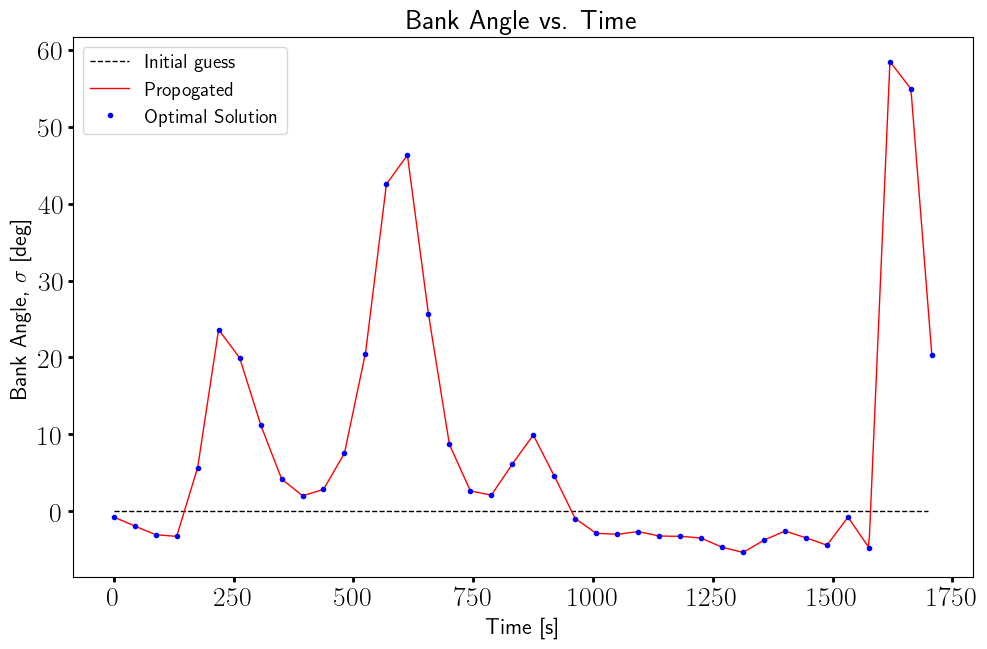

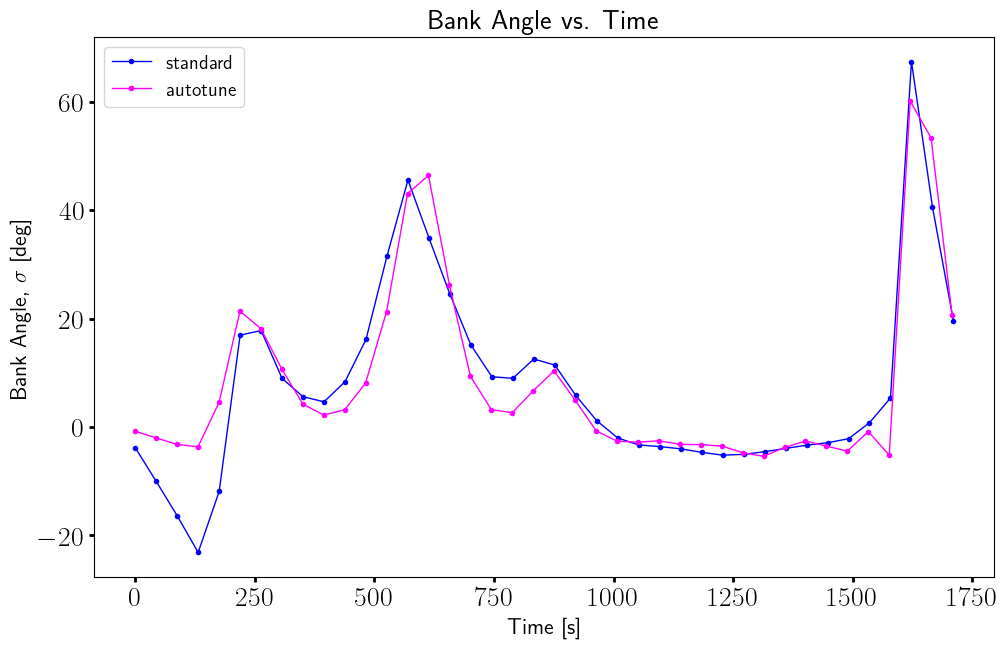

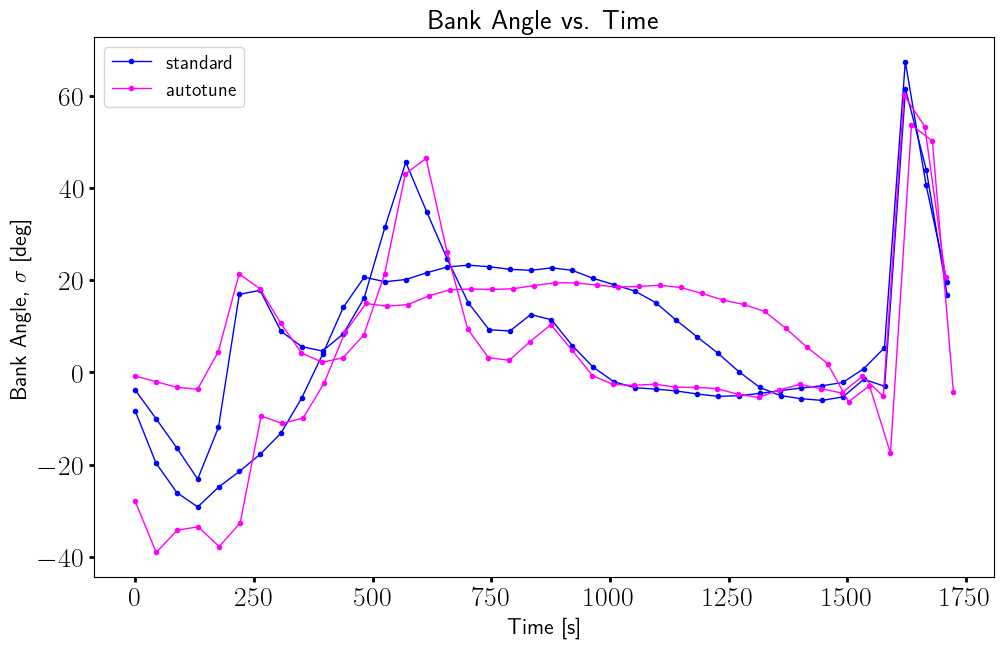

In [7]:
### TO FIX
### ================================================ ###
sind = 0; # STATE INDEX FOR BANK ANGLE 
### ================================================ ###

versions = ['base','methods'];
if use_montecarlo: versions = versions + ['mc'];
fignames = ['bank1.pdf','bank2.pdf','bank3.pdf'];

for kk,version in enumerate(versions): 

    if version == 'base':
        scenarios = ['scenario1'];
        methods = ['autotune'];
        itrs_all = list(range(1000))[2:]; runs = [0]; 
    if version == 'methods':
        scenarios = ['scenario1'];
        methods = ['standard','autotune']; 
        itrs_all = list(range(1000))[2:]; runs = [0]; 
    if version == 'mc':
        scenarios = ['scenario1'];
        methods = ['standard','autotune']; 
        itrs_all = list(range(1000))[2:]; runs = list(range(1000)); 

    # grid = PLTS1.specGrid(typ='2x2'); 
    fig = plt.figure(figsize=(10,6));
    grid = {};
    grid[(0,0)] = [0.5,0.5,0.9,0.9];
    axs = PLTS1.createGrid(fig,grid = grid);

    state_inds = [sind];
    state_plot_inds = {sind:(0,0)};
    state_names = {sind:'Bank Angle'};

    titles = {}; ylabels = {};
    titles[(0,0)] = 'Bank Angle vs. Time';
    ylabels[(0,0)] = 'Bank Angle, $\sigma$ [deg]';

    lgnd = 'Fig5'; PLTS1.dumpLegend(lgnd);


    for method in methods:
        for sind in state_inds:
            aind = state_plot_inds[sind];
            ax = axs[aind];
            PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})
            if version == 'base':
                params1 = {'label':'Initial guess','x':'t_nl','y':('u_nl',sind),'iters':[0],'legend':lgnd};
                params2 = {'label':'Iterations','x':'t','y':('u',sind),'iters':itrs_all,'legend':lgnd};
                params3 = {'label':'Propogated','x':'t_nl','y':('u_nl',sind),'iters':[-1],'legend':lgnd};
                params4 = {'label':'Optimal Solution','x':'t','y':('u',sind),'iters':[-2],'legend':lgnd};

                PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
                # PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
                PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
                PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
            if version == 'methods':
                params4 = {'label':method,'x':'t','y':('u',sind),'iters':[-1],'legend':lgnd};
                PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 

            if version == 'mc':
                params4 = {'label':method,'x':'t','y':('u',sind),'iters':[-1],'legend':lgnd};
                PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 


            params = {};
            params['title'] = {'text':titles[aind],'fontsize':20}
            params['xlabel'] = {'label':'Time [s]','fontsize':16}
            params['ylabel'] = {'label':ylabels[aind],'fontsize':16}
            params['ticks'] = {'labelsize':20,'width':2};
            PLTS1.setParams(ax,params);
            PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

    if printfigs: 
        figname = figpath + fignames[kk]; #'bankangle1.pdf'
        plt.savefig(figname,bbox_inches='tight',pad_inches = 0,transparent=transparentfigs);





# Fig. 19 - version with both bank angle and angle of attack (angle of attack is not in vtol data)

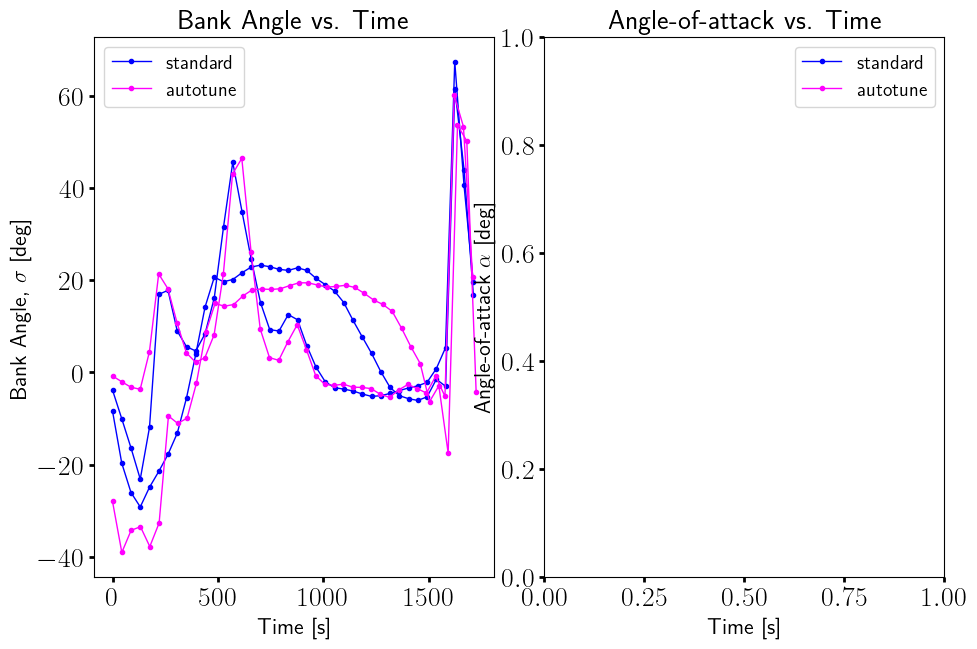

In [8]:
### TO FIX
### ================================================ ###
sind = 0; # STATE INDEX FOR BANK ANGLE 
### ================================================ ###

# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.05,0.05,0.4,0.9];
grid[(0,1)] = [0.50,0.05,0.4,0.9];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [0,1];
state_plot_inds = {0:(0,0),1:(0,1)};
state_names = {sind:'Bank Angle'};

titles = {}; ylabels = {};
titles[0] = 'Bank Angle vs. Time';
titles[1] = 'Angle-of-attack vs. Time';
ylabels[0] = 'Bank Angle, $\sigma$ [deg]';
ylabels[1] = 'Angle-of-attack $\\alpha$ [deg]';

scenarios = ['scenario1'];
methods = ['standard','autotune']; # methods = ['standard','autotune'];

lgnd = 'Fig12'; PLTS1.dumpLegend(lgnd)
itrs_all = list(range(1000))[2:]; runs = list(range(1000));
# for j,sind in enumerate(state_inds):
for method in methods:
    PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})
    ax = axs[(0,0)];
    params = {'label':method,'x':'t','y':('u',0),'iters':[-1],'legend':lgnd};
    PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params); 
    # ax = axs[(0,1)];
    # params = {'label':method,'x':'t','y':('u',1),'iters':[-1],'legend':lgnd};
    # PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params); 

for j in [0,1]:
    ax = axs[state_plot_inds[j]];
    params = {};
    params['title'] = {'text':titles[j],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[j],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


if printfigs: 
    figname = figpath + 'bankplusAOA.pdf'
    plt.savefig(figname,bbox_inches='tight',pad_inches = 0,transparent=transparentfigs);




# Fig.6, Fig.13, Fig.20 - Trajectories 

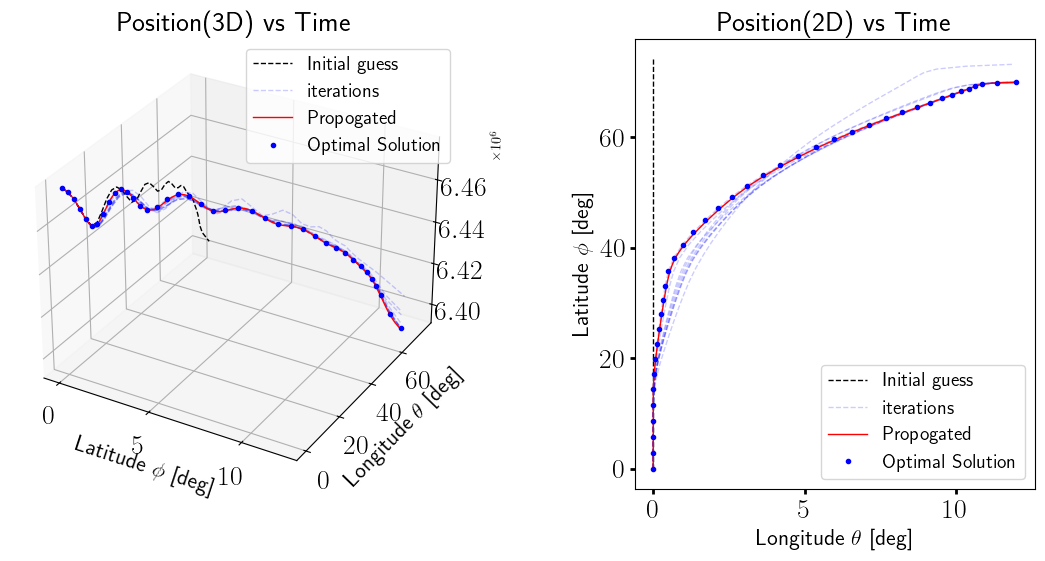

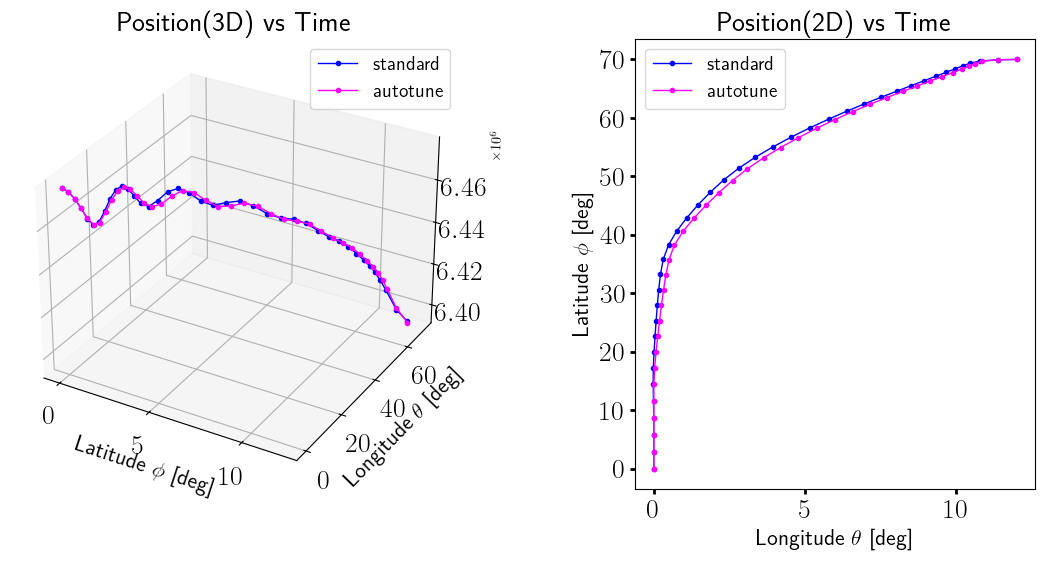

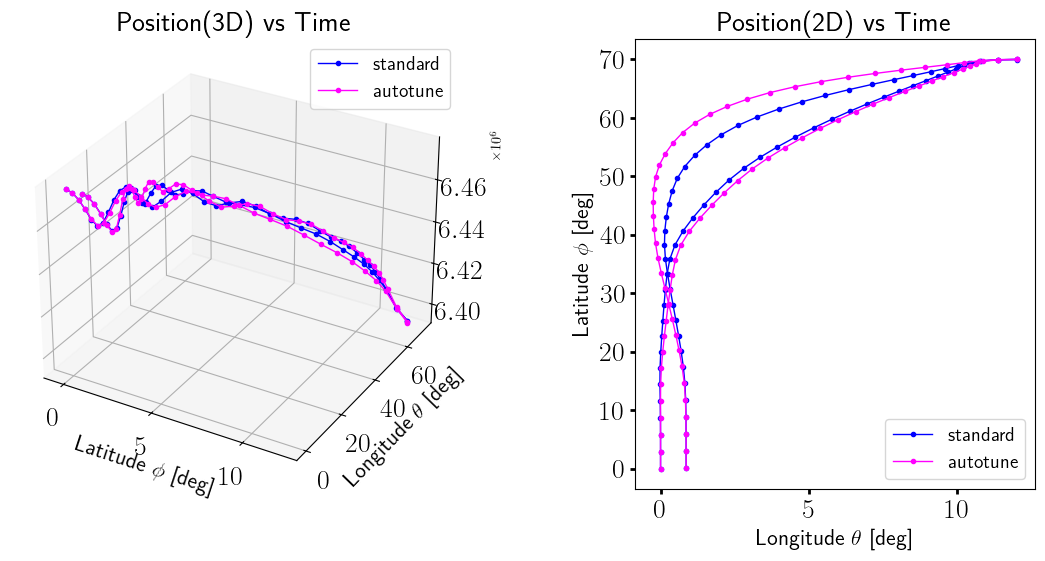

In [9]:

versions = ['base','methods'];
if use_montecarlo: versions = versions + ['mc'];
fignames = ['trajectories1.pdf','trajectories2.pdf','trajectories3.pdf'];


for kk,version in enumerate(versions): 
    
    # grid = PLTS1.specGrid(typ='2x2'); 
    fig = plt.figure(figsize=(10,5));
    grid2D = {}; grid3D = {};
    grid3D[(0,0)] = [0.05,0.05,0.5,0.9]; 
    grid2D[(0,1)] = [0.70,0.05,0.4,0.9];

    axs1 = PLTS1.createGrid(fig,grid = grid2D);
    # axs2 = PLTS1.createGrid(fig,grid = grid3D,ins={'plt_typ':'3d'});
    axs2 = {(0,0): fig.add_axes(grid3D[(0,0)],projection='3d')} # colorbar axis]
    axs = {**axs1,**axs2};

    state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};

    titles = {}; ylabels = {}; xlabels = {}; zlabels = {};
    titles[0] = 'Position(3D) vs Time';
    titles[1] = 'Position(2D) vs Time';

    xlabels[0] = 'Latitude $\phi$ [deg]';
    ylabels[0] = 'Longitude $\\theta$ [deg]';
    zlabels[0] = 'Altitude $h$ [km]';

    ylabels[1] = 'Latitude $\phi$ [deg]';
    xlabels[1] = 'Longitude $\\theta$ [deg]';

    scenarios = ['scenario1'];
    if version == 'base':     
        methods = ['autotune'];
        itrs = list(range(1000))[2:]; 
        runs = [0]; #list(range(1000)); itrs = [-1];
    if version == 'methods':
        methods = ['standard','autotune'];
        runs = [0];
        itrs = [-2];
    if version == 'mc':
        methods = ['standard','autotune'];
        runs = list(range(1000));
        itrs = [-1];

    lgnd = 'Fig6'; PLTS1.dumpLegend(lgnd)
    j = 1;
    
    
    # itrs_all = list(range(1000))[2:]; 
    
    for method in methods: 

        PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})
        ax = axs[(0,1)]; #state_plot_inds[j]];
        sindx = 1; sindy = 2; j = 1;
        if version == 'base':
            params1 = {'label':'Initial guess','x':('z_nl',sindx),'y':('z_nl',sindy),'iters':[0],'legend':lgnd,};
            params2 = {'label':'iterations','x':('z',sindx),'y':('z',sindy),'iters':itrs,'legend':lgnd};
            params3 = {'label':'Propogated','x':('z_nl',sindx),'y':('z_nl',sindy),'iters':[-1],'legend':lgnd};
            params4 = {'label':'Optimal Solution','x':('z',sindx),'y':('z',sindy),'iters':[-1],'legend':lgnd};

            PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
            PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
            PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
            PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4);

        if version == 'methods':
            params1 = {'label':method,'x':('z',sindx),'y':('z',sindy),'iters':[-1],'legend':lgnd};
            PLTS1.addPlot2D(ax,pen=PENS[method],ins=params1);

        if version == 'mc':
            params1 = {'label':method,'x':('z',sindx),'y':('z',sindy),'iters':[-1],'legend':lgnd};
            PLTS1.addPlot2D(ax,pen=PENS[method],ins=params1);

        params = {};
        params['title'] = {'text':titles[1],'fontsize':20}
        params['xlabel'] = {'label':xlabels[1],'fontsize':16}
        params['ylabel'] = {'label':ylabels[1],'fontsize':16}
        params['ticks'] = {'labelsize':20,'width':2};
        PLTS1.setParams(ax,params);
        PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

        ax = axs[(0,0)];
        sindx = 1; sindy = 2; sindz = 0; 
        if version == 'base':
            params1 = {'label':'Initial guess','x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':[1],'legend':lgnd,};
            params2 = {'label':'iterations','x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':itrs_all,'legend':lgnd};
            params3 = {'label':'Propogated','x':('z_nl',sindx),'y':('z_nl',sindy),'z':('z_nl',sindz),'iters':[-1],'legend':lgnd};
            params4 = {'label':'Optimal Solution','x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':[-1],'legend':lgnd};

            PLTS1.addPlot3D(ax,pen=PENS['init'],ins=params1);
            PLTS1.addPlot3D(ax,pen=PENS['itr'] ,ins=params2);
            PLTS1.addPlot3D(ax,pen=PENS['prop'],ins=params3); 
            PLTS1.addPlot3D(ax,pen=PENS['opt'] ,ins=params4);     

        if version == 'methods':
            params1 = {'label':method,'x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':[-1],'legend':lgnd};
            PLTS1.addPlot3D(ax,pen=PENS[method],ins=params1);

        if version == 'mc':
            params1 = {'label':method,'x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':[-1],'legend':lgnd};
            PLTS1.addPlot3D(ax,pen=PENS[method],ins=params1);


        params = {};
        params['title'] = {'text':titles[0],'fontsize':20}
        params['xlabel'] = {'label':xlabels[0],'fontsize':16}
        params['ylabel'] = {'label':ylabels[0],'fontsize':16}
        params['zlabel'] = {'label':zlabels[0],'fontsize':16}
        params['ticks'] = {'labelsize':20,'width':2};
        PLTS1.setParams(ax,params);
        PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

    if printfigs: 
        figname = figpath + fignames[kk]; #'bankangle1.pdf'
        plt.savefig(figname,bbox_inches='tight',pad_inches = 0,transparent=transparentfigs);





# Fig. 7, Fig.14,Fig.21 - States

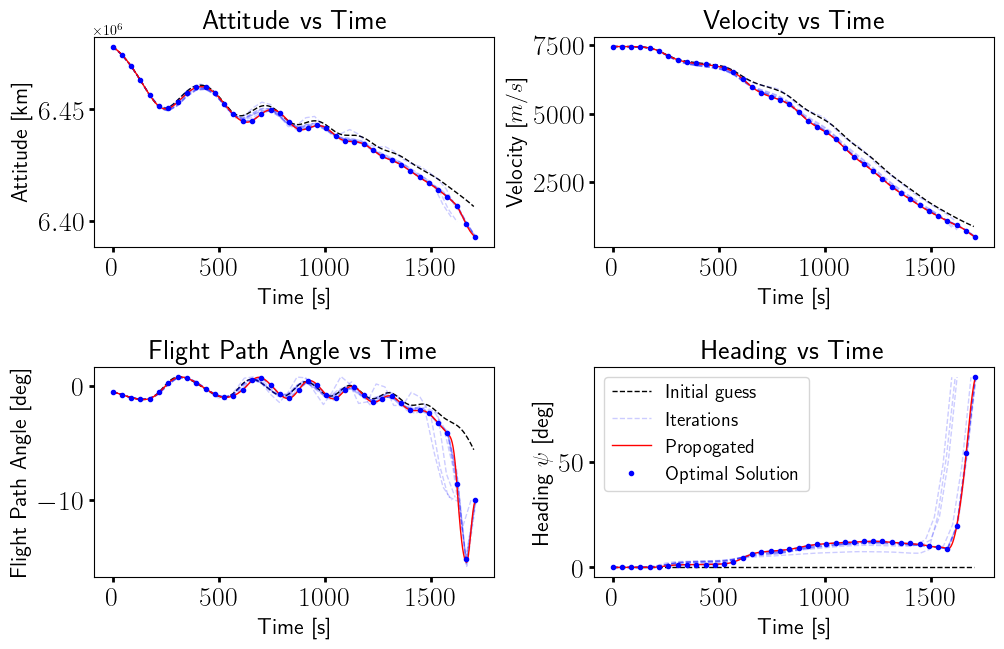

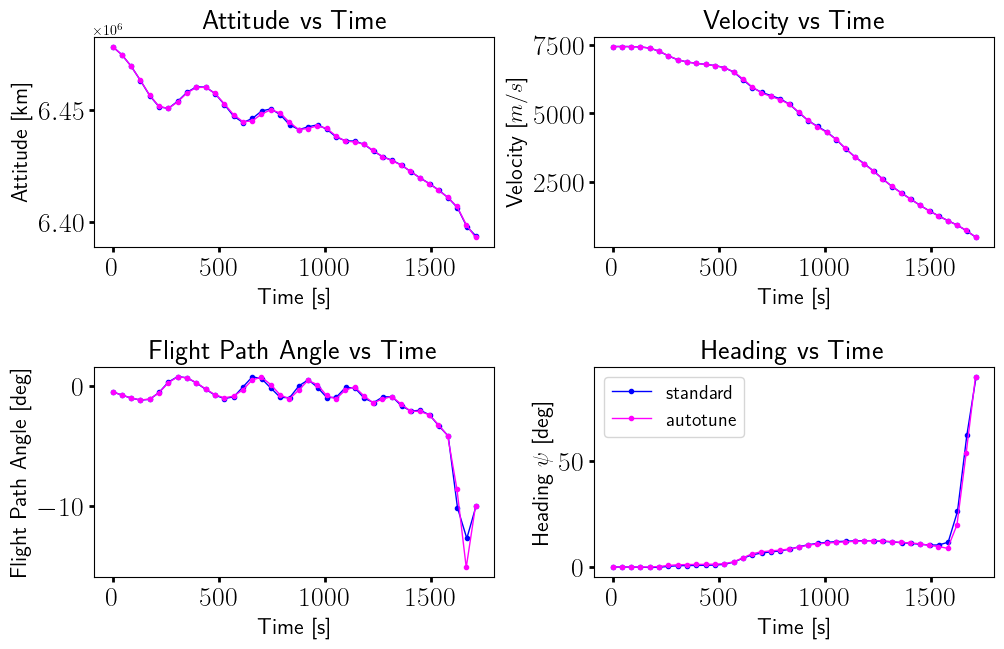

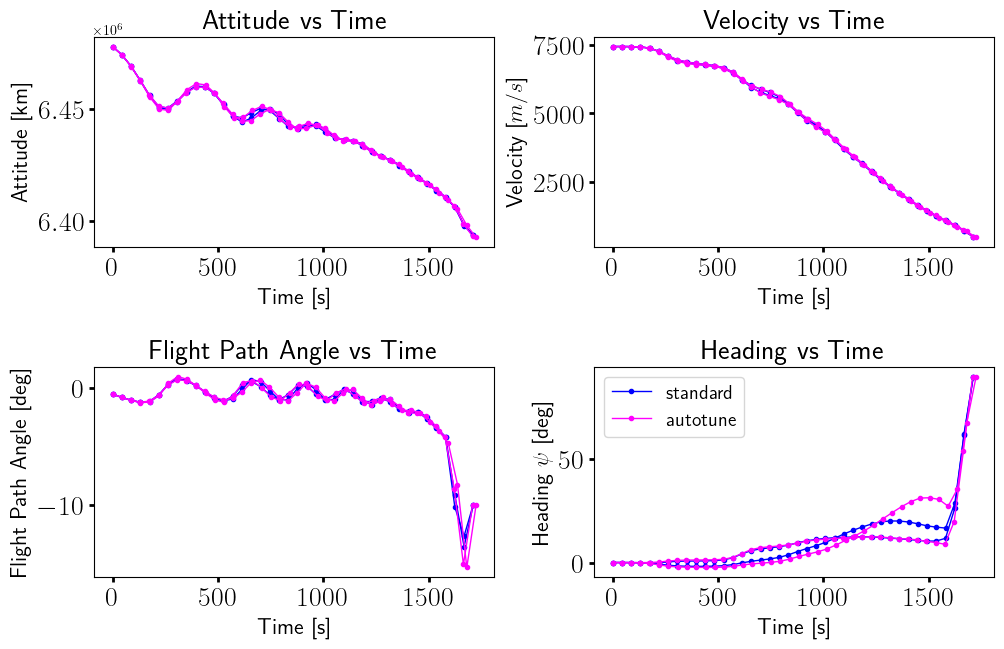

In [10]:
versions = ['base','methods'];
if use_montecarlo: versions = versions + ['mc'];
fignames = ['states1.pdf','states2.pdf','states3.pdf'];

for kk,version in enumerate(versions): 

    # grid = PLTS1.specGrid(typ='2x2'); 
    fig = plt.figure(figsize=(10,6));
    grid = {};
    grid[(1,1)] = [0.55,0.05,0.4,0.35];
    grid[(0,1)] = [0.55,0.6,0.4,0.35];
    grid[(1,0)] = [0.05,0.05,0.4,0.35];
    grid[(0,0)] = [0.05,0.6,0.4,0.35];
    axs = PLTS1.createGrid(fig,grid = grid);

    state_inds = [0,3,4,5] # replace with appropriate state indices
    state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};

    state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};

    titles = {}; ylabels = {};
    titles[2] = 'Flight Path Angle vs Time';
    titles[3] = 'Heading vs Time';
    titles[0] = 'Attitude vs Time';
    titles[1] = 'Velocity vs Time';

    ylabels[2] = 'Flight Path Angle [deg]';
    ylabels[3] = 'Heading $\psi$ [deg]';
    ylabels[0] = 'Attitude [km]';
    ylabels[1] = 'Velocity [$m/s$]';

    lgnd = 'Fig7'; PLTS1.dumpLegend(lgnd)

    if version == 'base':
        scenarios = ['scenario1'];
        methods = ['autotune'];
        itrs = list(range(1000))[2:];
        runs = [0];#list(range(1000));
    if version == 'methods':
        methods = ['standard','autotune'];
        runs = [0];
    if version == 'mc':
        methods = ['standard','autotune'];
        runs = list(range(1000));        


    for method in methods: 
        for j,sind in enumerate(state_inds):
            ax = axs[state_plot_inds[j]];
            PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

            if version == 'base':
                params1 = {'label':'Initial guess','x':'t_nl','y':('z_nl',sind),'iters':[0],'legend':lgnd,};
                params2 = {'label':'Iterations','x':'t','y':('z',sind),'iters':itrs,'legend':lgnd};
                params3 = {'label':'Propogated','x':'t_nl','y':('z_nl',sind),'iters':[-1],'legend':lgnd};
                params4 = {'label':'Optimal Solution','x':'t','y':('z',sind),'iters':[-1],'legend':lgnd};

                PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
                PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
                PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
                PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
            
            if version == 'methods':
                params4 = {'label':method,'x':'t','y':('z',sind),'iters':[-1],'legend':lgnd};
                PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 
        

            if version == 'mc':

                params4 = {'label':method,'x':'t','y':('z',sind),'iters':[-1],'legend':lgnd};
                PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 
    

            params = {};
            params['title'] = {'text':titles[j],'fontsize':20}
            params['xlabel'] = {'label':'Time [s]','fontsize':16}
            params['ylabel'] = {'label':ylabels[j],'fontsize':16}
            params['ticks'] = {'labelsize':20,'width':2};
            PLTS1.setParams(ax,params);
            if j == 3: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


    if printfigs: 
        figname = figpath + fignames[kk]; #'bankangle1.pdf'
        plt.savefig(figname,bbox_inches='tight',pad_inches = 0,transparent=transparentfigs);


In [11]:
# temp = PLTS1.data['scenario1']['autotune']['mc_data'][0]['iters'][2]['max_load']
# print(temp)
# # print(list(temp))
# # print(temp['max_q'])

# Fig.8, Fig.15, Fig. 22 Loads,heat rate etc. 

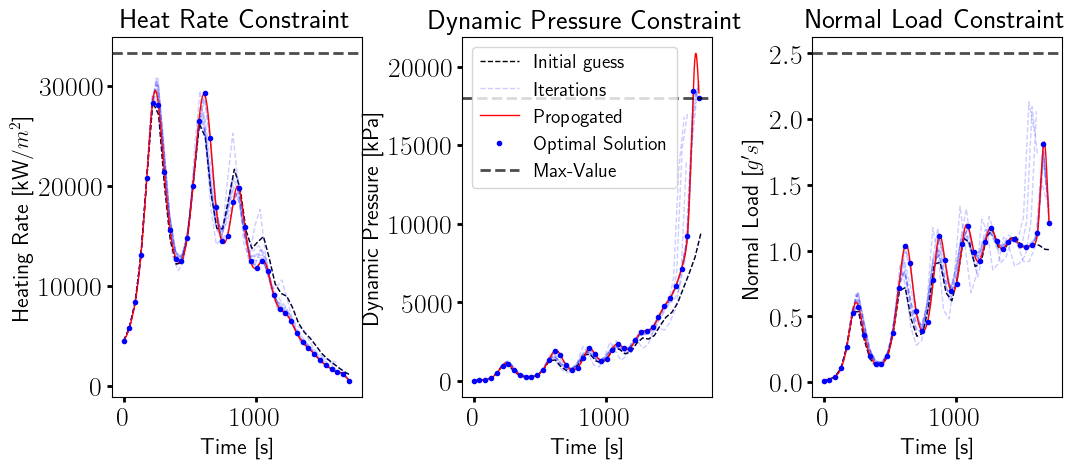

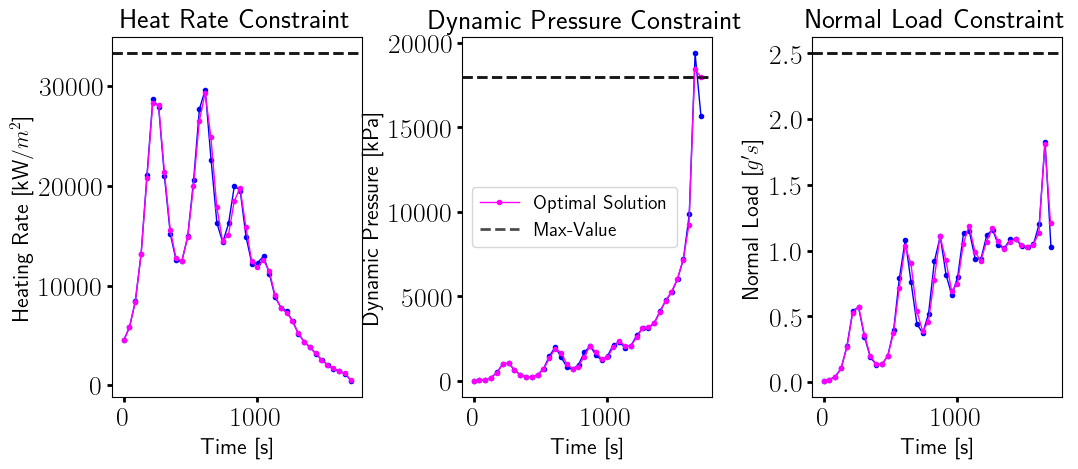

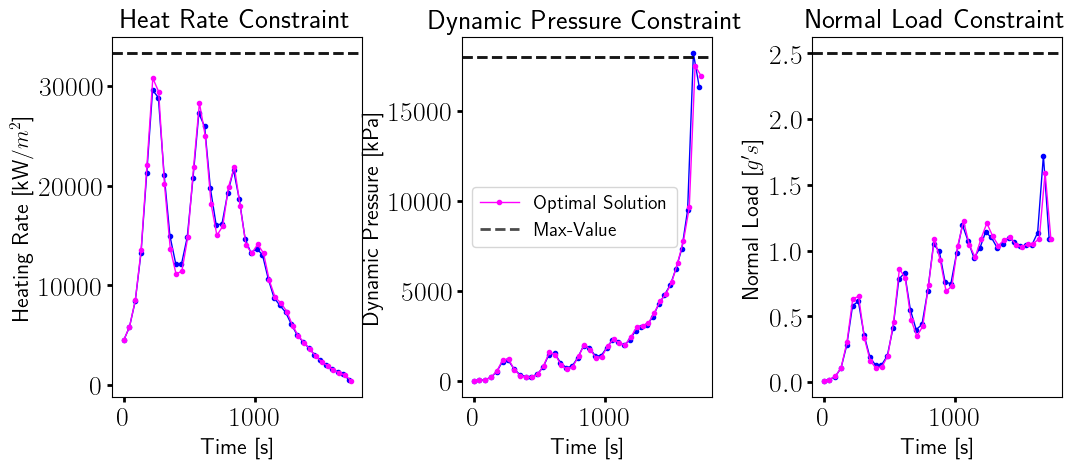

In [12]:
versions = ['base','methods'];
if use_montecarlo: versions = versions + ['mc'];
fignames = ['loads1.pdf','loads2.pdf','loads3.pdf'];

for kk,version in enumerate(versions):

    # grid = PLTS1.specGrid(typ='2x2'); 
    fig = plt.figure(figsize=(10,4));
    grid = {};
    grid[(0,0)] = [0.05,0.05,0.25,0.9];
    grid[(0,1)] = [0.4,0.05,0.25,0.9];
    grid[(0,2)] = [0.75,0.05,0.25,0.9];

    axs = PLTS1.createGrid(fig,grid = grid);

    tags = ['max_Q','max_q','max_load']
    state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};



    state_plot_inds = {0:(0,0),1:(0,1),2:(0,2)};


    titles = {}; ylabels = {};

    titles[0] = 'Heat Rate Constraint';
    titles[1] = 'Dynamic Pressure Constraint';
    titles[2] = 'Normal Load Constraint';

    ylabels[0] = 'Heating Rate [kW/$m^2$]';
    ylabels[1] = 'Dynamic Pressure [kPa]';
    ylabels[2] = 'Normal Load [$g\'s$]';

    scenarios = ['scenario1'];
    if version == 'base':
        methods = ['autotune'];
        itrs = list(range(1000))[1:];
        runs = [0];
    if version == 'methods':
        methods = ['standard','autotune'];
        runs = [0];
    if version == 'mc':
        methods = ['standard','autotune'];
        runs = list(range(1000))[1:];

    lgnd = 'Fig8'; PLTS1.dumpLegend(lgnd);

    for method in methods: 
        for j,tag in enumerate(tags):            
            ax = axs[state_plot_inds[j]];
            PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

            if version == 'base':
                params1 = {'label':'Initial guess','x':'t','y':tag + '_sub','iters':[1],'legend':lgnd,};
                params2 = {'label':'Iterations','x':'t','y':tag + '_sub','iters':itrs,'legend':lgnd};
                params3 = {'label':'Propogated','x':'t_nl','y':tag + '_nl','iters':[-1],'legend':lgnd};
                params4 = {'label':'Optimal Solution','x':'t','y':tag + '_sub','iters':[-1],'legend':lgnd};

                PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
                PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
                PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
                PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4);
            if version == 'methods':
                # params1 = {'label':'Initial guess','x':'t_nl','y':tag,'iters':[1],'legend':lgnd,};
                # params2 = {'label':'iterations','x':'t_nl','y':tag,'iters':itrs_all,'legend':lgnd};
                params3 = {'label':'Propogated','x':'t_nl','y':tag + '_nl','iters':[-1],'legend':lgnd};
                params4 = {'label':'Optimal Solution','x':'t','y':tag + '_sub','iters':[-1],'legend':lgnd};
                # PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params3);         
                PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 
    
            if version == 'mc':
                # params1 = {'label':'Initial guess','x':'t_nl','y':tag,'iters':[1],'legend':lgnd,};
                # params2 = {'label':'iterations','x':'t_nl','y':tag,'iters':itrs_all,'legend':lgnd};
                params3 = {'label':'Propogated','x':'t_nl','y':tag + '_nl','iters':[-1],'legend':lgnd};
                params4 = {'label':'Optimal Solution','x':'t','y':tag + '_sub','iters':[-1],'legend':lgnd};
                # PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params3);         
                PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 

            #### hack for adding max value line... not that hacky anyway
            line_tag = 'Max-Value'
            maxval = problem.mission.path_limits[tag];
            if tag == 'max_load': maxval = maxval/problem.mission.planet['g']
            line_handle = ax.axhline(y=maxval, color=[0,0,0,0.7], linestyle='--', linewidth=2, label=line_tag)
            PLTS1.legends[lgnd][line_tag] = line_handle;

            
            params = {};
            params['title'] = {'text':titles[j],'fontsize':20}
            params['xlabel'] = {'label':'Time [s]','fontsize':16}
            params['ylabel'] = {'label':ylabels[j],'fontsize':16}
            params['ticks'] = {'labelsize':20,'width':2};
            PLTS1.setParams(ax,params);
            if j==1: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


    if printfigs: 
        figname = figpath + fignames[kk]; #'bankangle1.pdf'
        plt.savefig(figname,bbox_inches='tight',pad_inches = 0,transparent=transparentfigs);


In [13]:
# temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]['weights'];#params']['method']['weights']['W_dyn'];
temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]['conv_data'];#['chk_feas_ineq'];#params']['method']['weights']['W_dyn'];
# ['w_cost', 'alpha_z', 'alpha_u', 'beta', 'gamma', 'eps_nonzero1',
#  'eps_nonzero2', 'wbuff', 'w_path_scale', 'w_custom_scale', 'w_nfz_scale',
#  'w_dyn_scale', 'w_term_scale',

#  'W_ineq', 'W_term', 'W_dyn', 'W_plus','W_minus',
#  'dual_ineq', 'dual_term', 'dual_dyn', 'dual_plus', 'dual_minus',

#  'wtr_z', 'wtr_u', 'w_fac_N', 'w_fac_Nm1', 'w_ctcs', 'data']


# print(temp)
# print(list(temp))
# print(temp['W_ineq'])

In [14]:

temp = data['scenario1']['autotune']['mc_data'][1]['iters'][-1]['weights'];
# print(temp['weights']['W_ineq'])
print(temp['W_ineq'].shape)
inds = problem.indices.constraints.nonlinear_inequality['path']; #))
# plt.plot(temp['W_ineq'][:,inds])

(40, 5)


problem.indices.constraints.nonlinear_inequality['nfz']

# Fig.9 

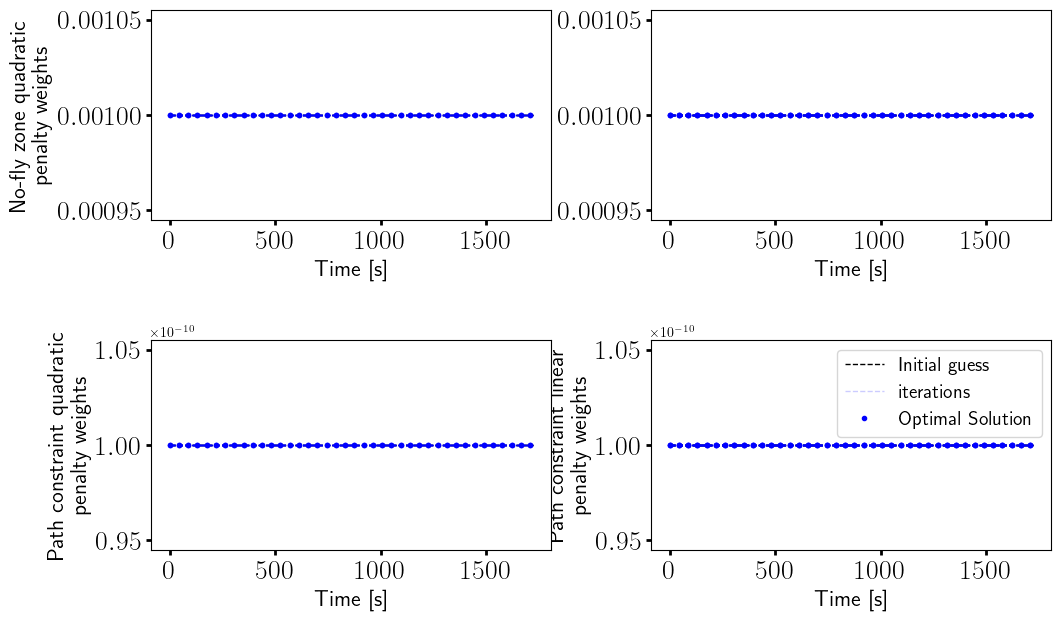

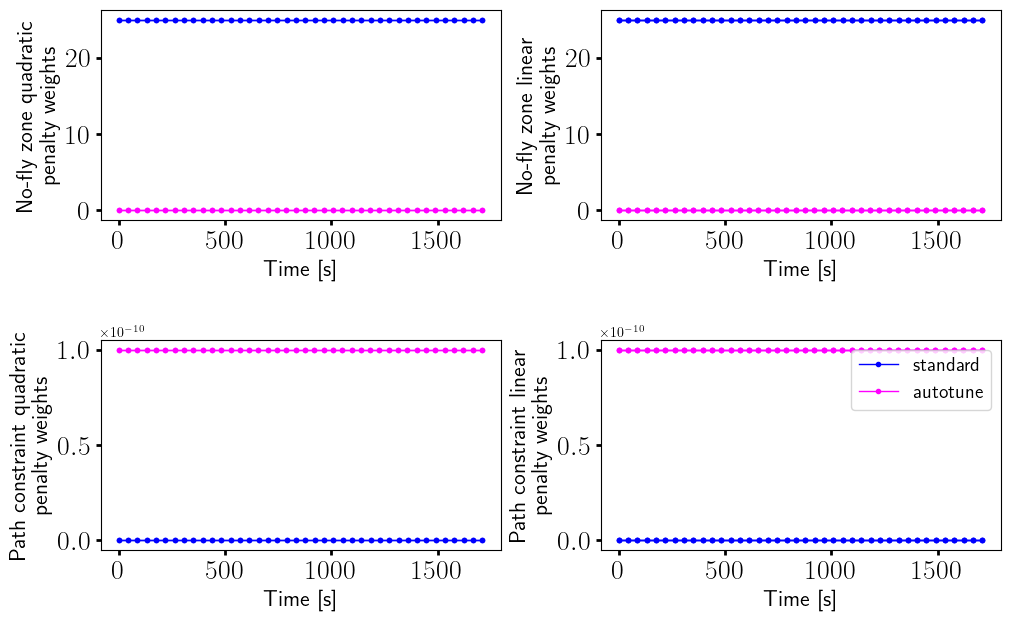

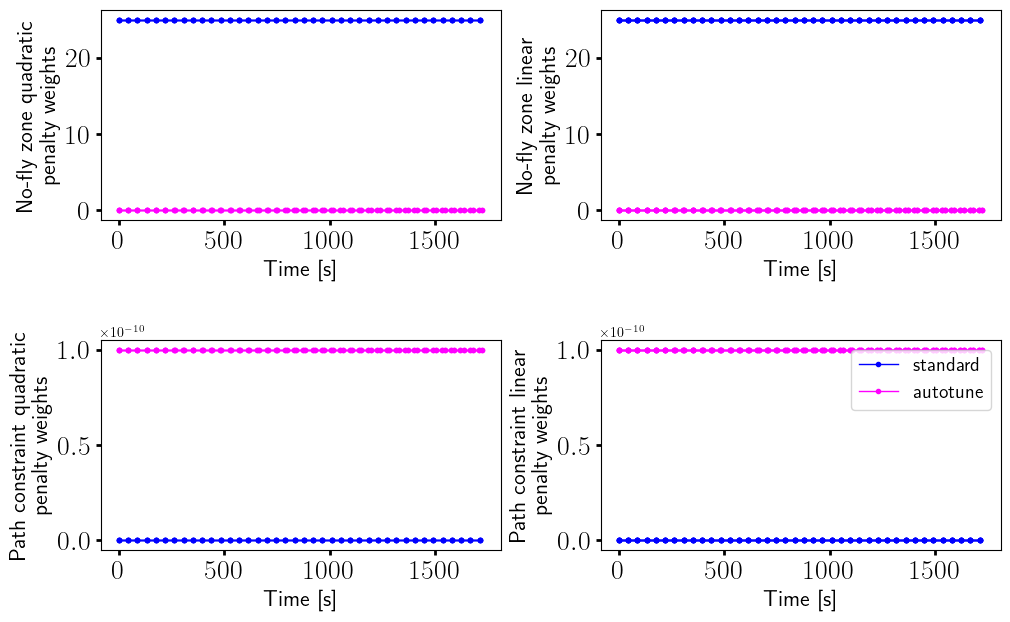

In [15]:
versions = ['base','methods'];
if use_montecarlo: versions = versions + ['mc'];
fignames = ['weights1','weights2.pdf','weights3.pdf'];

for kk,version in enumerate(versions):

    # grid = PLTS1.specGrid(typ='2x2'); 
    fig = plt.figure(figsize=(10,6));
    grid = {};
    grid[(1,1)] = [0.55,0.05,0.4,0.35];
    grid[(0,1)] = [0.55,0.6,0.4,0.35];
    grid[(1,0)] = [0.05,0.05,0.4,0.35];
    grid[(0,0)] = [0.05,0.6,0.4,0.35];
    axs = PLTS1.createGrid(fig,grid = grid);

    state_inds = [0,3,4,5] # replace with appropriate state indices
    state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};

    state_plot_inds = {0:(0,0),1:(1,0),2:(0,1),3:(1,1)};

    titles = {}; ylabels = {};
    titles[0] = ''; titles[1] = ''; titles[2] = ''; titles[3] = '';

    ylabels[0] = 'No-fly zone quadratic \n penalty weights';
    ylabels[1] = 'Path constraint quadratic \n penalty weights';
    ylabels[2] = 'No-fly zone linear \n penalty weights';
    ylabels[3] = 'Path constraint linear \n penalty weights';



    # weight_info = weights = 
    nfz_inds = problem.indices.constraints.nonlinear_inequality['nfz'];
    pth_inds = winds = problem.indices.constraints.nonlinear_inequality['path'];

    weight_info = [['W_ineq',nfz_inds],
                ['dual_ineq',nfz_inds],
                ['W_ineq',pth_inds],
                ['dual_ineq',pth_inds]];

    #'W_term','W_dyn']; #,'W_plus','W_minus']
    # 'W_ineq' -> path constraints
    # 'W_term' -> terminal condition
    # 'W_dyn', -> dynamics
    # 'W_plus', 'W_minus', -> the weird quadratic 1-norm 
    # 'dual_ineq', 'dual_term', 'dual_dyn', 'dual_plus', 'dual_minus', <- dual versions

    if version == 'base':
        scenarios = ['scenario1'];
        methods = ['autotune'];
        itrs = list(range(1000))[1:];
        runs = [0]; 
    if version == 'methods':
        methods = ['standard','autotune']
        runs = [0]; #list(range(1000));
    if version == 'mc':
        methods = ['standard','autotune']
        runs = list(range(1000));

    lgnd = 'Fig9'; PLTS1.dumpLegend(lgnd)

    PENS['opt_weight']      = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_0']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_1']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.2,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_2']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.4,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_3']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.6,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_4']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.8,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_5']    = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};


    for method in methods: 

        for j,info in enumerate(weight_info):
            weight = info[0]; winds = info[1]
            ax = axs[state_plot_inds[j]];
            PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

            if version == 'base': 
                params1 = {'label':'Initial guess','x':'t','y':(weight,winds),'iters':[1],'legend':lgnd,'dataloc':'weights'};
                params2 = {'label':'iterations','x':'t','y':(weight,winds),'iters':itrs,'legend':lgnd,'dataloc':'weights'};
                # params3 = {'label':'Propogated','x':'t_nl','y':weight,'iters':[-1],'legend':lgnd,'dataloc':'weights'};
                params4 = {'label':'Optimal Solution','x':'t','y':(weight,winds),'iters':[-1],'legend':lgnd,'dataloc':'weights'};

                # try: 
                PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
                PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
                # PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
                PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4);
                # except: pass
            if version == 'methods':
                params4 = {'label':method,'x':'t','y':(weight,winds),'iters':[-1],'legend':lgnd,'dataloc':'weights'};
                PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4);

            if version == 'mc':
                params4 = {'label':method,'x':'t','y':(weight,winds),'iters':[-1],'legend':lgnd,'dataloc':'weights'};
                PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4);

            
            params = {};
            params['title'] = {'text':titles[j],'fontsize':20}
            params['xlabel'] = {'label':'Time [s]','fontsize':16}
            params['ylabel'] = {'label':ylabels[j],'fontsize':16}
            params['ticks'] = {'labelsize':20,'width':2};
            PLTS1.setParams(ax,params);
            if j == 3: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


    if printfigs: 
        figname = figpath + fignames[kk]; #'bankangle1.pdf'
        plt.savefig(figname,bbox_inches='tight',pad_inches = 0,transparent=transparentfigs);


# Fig.10, Fig. 17, Fig. 24 - Convergence Data

In [17]:
# temp = problem.method.subprob.iter_data[0]['conv_data']

# # print(list(PLTS1.data['scenario1']['method']))

# print(list(temp))
# print(temp['chk_feas_term'])

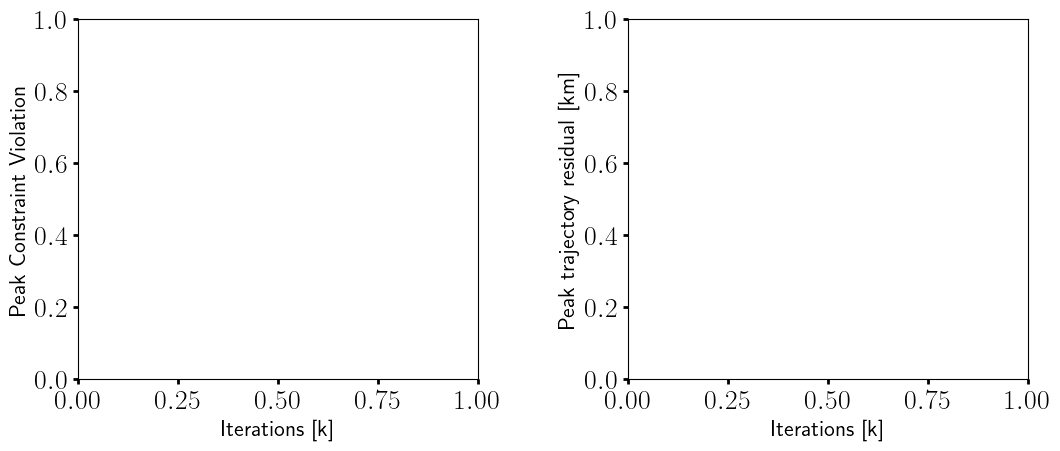

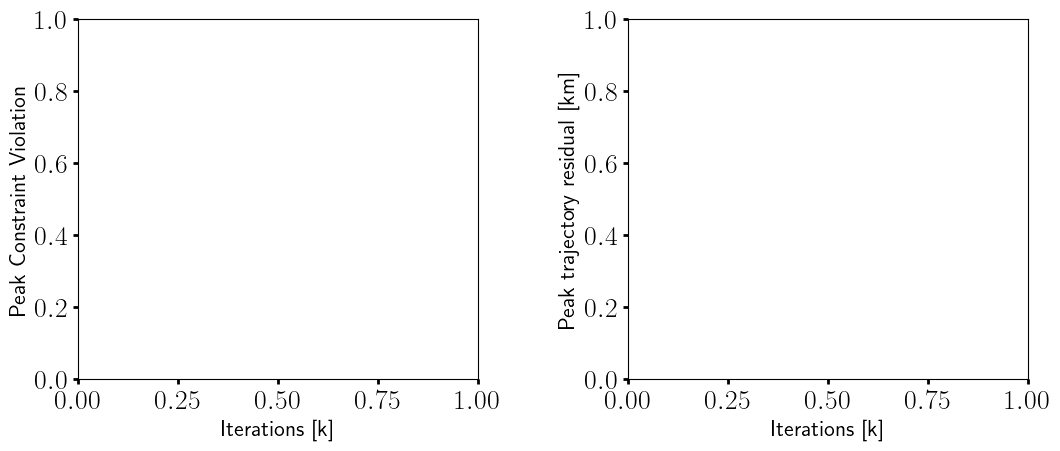

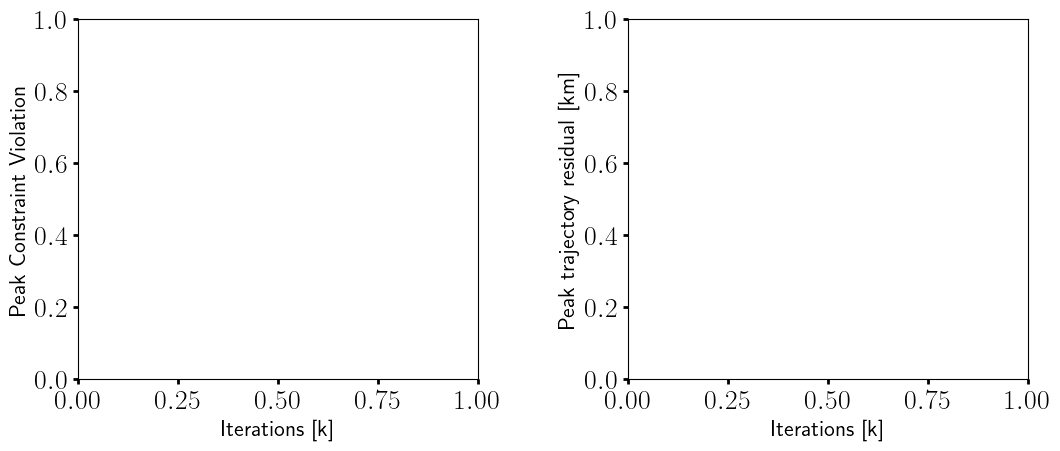

In [18]:
versions = ['base','methods'];
if use_montecarlo: versions = versions + ['mc'];
fignames = ['converge1','converge2.pdf','converge3.pdf'];

for kk,version in enumerate(versions):

    # grid = PLTS1.specGrid(typ='2x2'); 
    fig = plt.figure(figsize=(10,4));
    grid = {};
    grid[(0,0)] = [0.05,0.05,0.4,0.9];
    grid[(0,1)] = [0.6,0.05,0.4,0.9];
    axs = PLTS1.createGrid(fig,grid = grid);

    state_inds = [0,3,4,5] # replace with appropriate state indices
    state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};

    state_plot_inds = {0:(0,0),1:(0,1)}

    titles = {}; ylabels = {};
    titles[0] = ''; titles[1] = ''; titles[2] = ''; titles[3] = '';

    ylabels[0] = 'Peak Constraint Violation';
    ylabels[1] = 'Peak trajectory residual [km]';

    if version == 'base':
        scenarios = ['scenario1'];
        methods = ['autotune'];
        itrs = list(range(1000))[1:];
        runs = [0]; 
    if version == 'methods':
        methods = ['standard','autotune']
        runs = [0]; #list(range(1000));
    if version == 'mc':
        methods = ['standard','autotune']
        runs = list(range(1000));

    lgnd = 'Fig9'; PLTS1.dumpLegend(lgnd)

    PENS['opt_weight']      = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_0']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_1']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.2,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_2']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.4,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_3']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.6,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_4']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.8,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
    PENS['opt_weight_5']    = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};

    tags = ['chk_feas_term','chk_feas_dyn'];
    for method in methods: 
        for j,tag in enumerate(tags):
            ax = axs[state_plot_inds[j]];
            PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

            if version == 'base':
                lenval = len(problem.method.subprob.iter_data)
                ydat = [problem.method.subprob.iter_data[ii]['conv_data'][tag] for ii in range(lenval)[1:]]; 

            #     params1 = {'label':method,'tinds':[-1],'y':(tag,sind),'iters':[1],'legend':lgnd,'dataloc':'convergence'};
            #     PLTS1.addPlot2DIter(ax,pen=PENS['opt'] ,ins=params1); 
            # if version == 'methods': pass
            # if version == 'mc': pass

            params = {};
            params['title'] = {'text':titles[j],'fontsize':20}
            params['xlabel'] = {'label':'Iterations [k]','fontsize':16}
            params['ylabel'] = {'label':ylabels[j],'fontsize':16}
            params['ticks'] = {'labelsize':20,'width':2};
            PLTS1.setParams(ax,params);
            if j == 3: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


    if printfigs: 
        figname = figpath + fignames[kk]; #'bankangle1.pdf'
        plt.savefig(figname,bbox_inches='tight',pad_inches = 0,transparent=transparentfigs);


# Fig.11

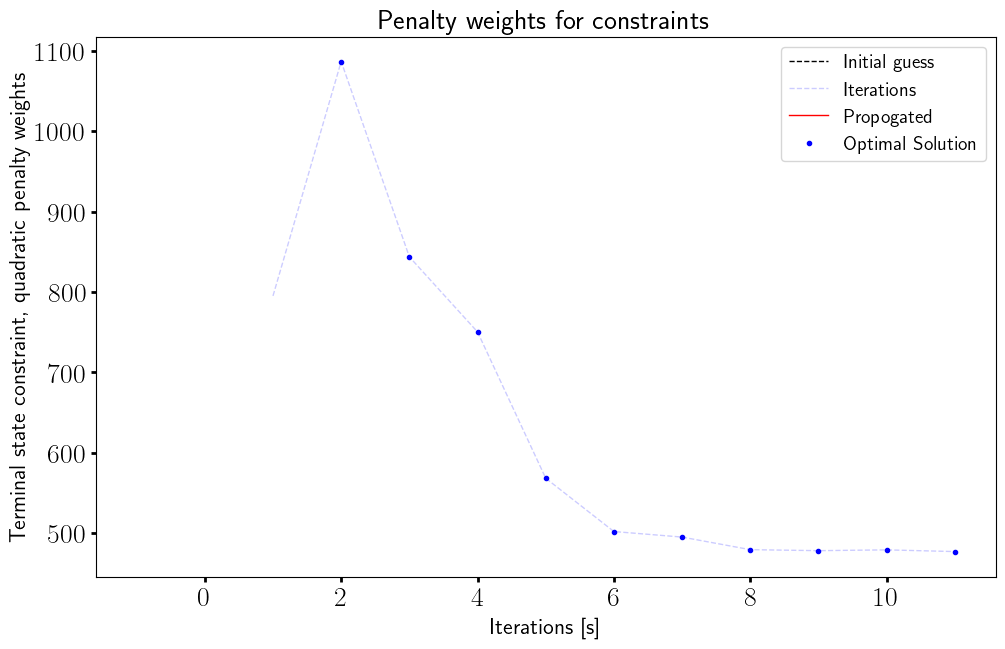

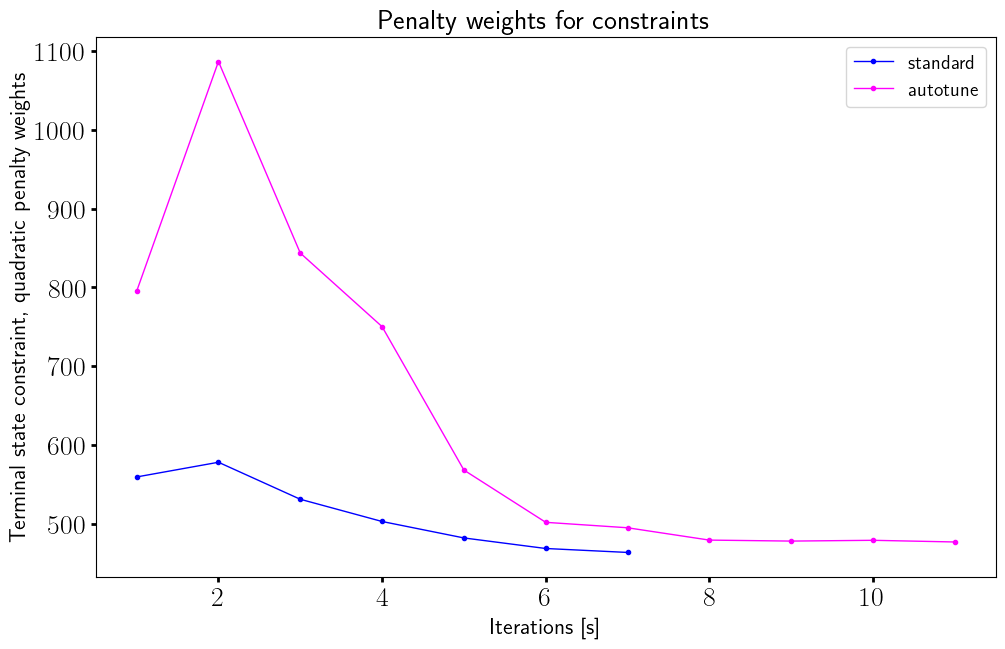

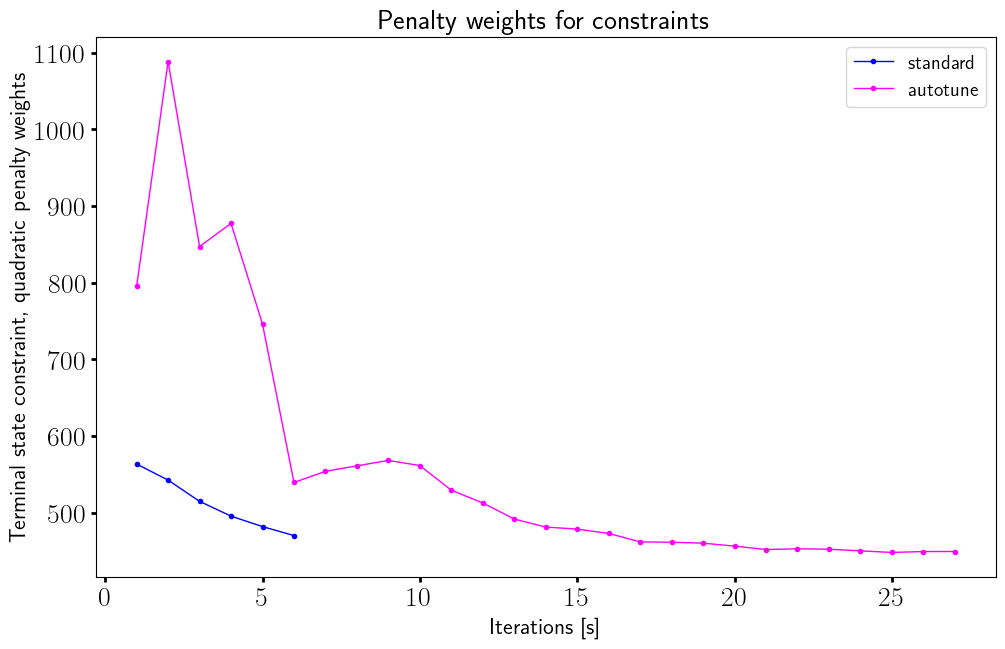

In [19]:
versions = ['base','methods'];
if use_montecarlo: versions = versions + ['mc'];
fignames = ['weightiters1','weightiters2.pdf','weightiters3.pdf'];



for kk,version in enumerate(versions):
    # grid = PLTS1.specGrid(typ='2x2'); 
    fig = plt.figure(figsize=(10,6));
    grid = {};
    grid[(0,0)] = [0.05,0.05,0.9,0.9];

    axs = PLTS1.createGrid(fig,grid = grid);
    sinds = [3] ;#tags = ['max_q','max_Q','max_load']
    state_names = {0:'Term. Altitude',
                1:'Term. Longitude',
                2:'Term. Latitude',
                3:'Term. Flight Path Angle',
                4:'Term. Heading'}

    scenarios = ['scenario1'];
    itrs = list(range(1000))[1:];
    if version == 'base':
        methods = ['autotune'];
        runs = [0]
    if version == 'methods':
        methods = ['standard','autotune'];
        runs = [0]
    if version == 'mc':
        methods = ['standard','autotune'];
        runs = list(range(1000))[1:];

    lgnd = 'Fig11'; PLTS1.dumpLegend(lgnd)
    state_plot_inds = {0:(0,0),1:(0,1),2:(0,2)};

    titles = {}; ylabels = {};
    titles[0] = 'Penalty weights for constraints';
    ylabels[0] = 'Terminal state constraint, quadratic penalty weights';

    for method in methods: 
        for j,sind in enumerate(sinds):
            ax = axs[state_plot_inds[0]];
            PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

            if version == 'base':
                params1 = {'label':'Initial guess','tinds':[-1],'y':('z',sind),'iters':[1],'legend':lgnd};
                params2 = {'label':'Iterations','tinds':[-1],'y':('z',sind),'iters':itrs,'legend':lgnd};
                params3 = {'label':'Propogated','tinds':[-1],'y':('z_nl',sind),'iters':[-1],'legend':lgnd};
                params4 = {'label':'Optimal Solution','tinds':[-1],'y':('z',sind),'iters':itrs_all,'legend':lgnd};
                PLTS1.addPlot2DIter(ax,pen=PENS['init'] ,ins=params1); 
                PLTS1.addPlot2DIter(ax,pen=PENS['itr'] ,ins=params2); 
                PLTS1.addPlot2DIter(ax,pen=PENS['prop'] ,ins=params3); 
                PLTS1.addPlot2DIter(ax,pen=PENS['opt'] ,ins=params4); 
            
            if version == 'methods':
                params1 = {'label':method,'tinds':[-1],'y':('z',sind),'iters':itrs,'legend':lgnd};
                PLTS1.addPlot2DIter(ax,pen=PENS[method] ,ins=params1); 
                            
            if version == 'mc':
                params1 = {'label':method,'tinds':[-1],'y':('z',sind),'iters':itrs,'legend':lgnd};
                PLTS1.addPlot2DIter(ax,pen=PENS[method] ,ins=params1); 

            params = {};
            params['title'] = {'text':titles[0],'fontsize':20}
            params['xlabel'] = {'label':'Iterations [s]','fontsize':16}
            params['ylabel'] = {'label':ylabels[0],'fontsize':16}
            params['ticks'] = {'labelsize':20,'width':2};
            PLTS1.setParams(ax,params);
        PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

    if printfigs: 
        figname = figpath + fignames[kk]; #'bankangle1.pdf'
        plt.savefig(figname,bbox_inches='tight',pad_inches = 0,transparent=transparentfigs);
